This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

这是《Deep Learning with Python, Third Edition》一书的配套 notebook。为了易读性，它仅包含可运行的代码块和章节标题，省略了书中的其他内容：文本段落、插图和伪代码。

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

**如果你想跟上进度，我建议边看书边对照此 notebook。**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

本书内容可在 [deeplearningwithpython.io](https://deeplearningwithpython.io) 在线查阅。

In [1]:
!pip install keras keras-hub --upgrade -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.26.0 requires keras-hub==0.26.0, but you have keras-hub 0.29.1 which is incompatible.


In [2]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

In [4]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    """自定义魔法命令：仅在指定的 Keras 后端环境下运行单元格。"""
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## The mathematical building blocks of neural networks
## 神经网络的数学基础

### A first look at a neural network
### 初探神经网络

In [5]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


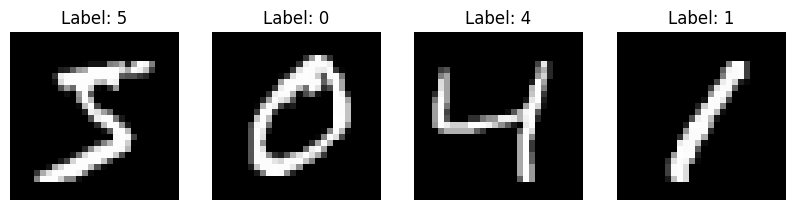

In [21]:
import matplotlib.pyplot as plt
from keras.datasets import mnist

# 重新加载原始形状的数据以便显示
(train_images_raw, train_labels_raw), _ = mnist.load_data()

plt.figure(figsize=(10, 4))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(train_images_raw[i], cmap='gray')
    plt.title(f"Label: {train_labels_raw[i]}")
    plt.axis('off')
plt.show()

In [6]:
train_images.shape

(60000, 28, 28)

In [7]:
len(train_labels)

60000

In [8]:
train_labels

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [9]:
test_images.shape

(10000, 28, 28)

In [10]:
len(test_labels)

10000

In [11]:
test_labels

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [12]:
import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

In [13]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [14]:
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

In [15]:
model.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9239 - loss: 0.2681
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9684 - loss: 0.1082
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9790 - loss: 0.0705
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9860 - loss: 0.0490
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9891 - loss: 0.0364


In [16]:
# 选择测试集中的前10个数字
test_digits = test_images[0:10]
# 使用模型对这些数字进行预测
predictions = model.predict(test_digits)
# 查看第一个测试样本的预测结果（概率分布）
predictions[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step


array([4.4538163e-07, 4.9770561e-09, 2.9232485e-06, 1.6149442e-04,
       3.4034536e-11, 1.5699091e-07, 1.9192670e-11, 9.9980927e-01,
       2.4324595e-07, 2.5362202e-05], dtype=float32)

In [17]:
# 找出预测概率最高的类别索引
predictions[0].argmax()

np.int64(7)

In [18]:
# 确认索引为7的预测概率值
predictions[0][7]

np.float32(0.99980927)

In [19]:
# 查看测试集中第一个标签的真实值
test_labels[0]

np.uint8(7)

In [20]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"test_acc: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9804 - loss: 0.0635
test_acc: 0.980400025844574


### 使用自己的手写数字图片进行预测
请运行以下单元格并上传一张包含手写数字的图片（建议背景简单，数字清晰）。

Saving 7.png to 7.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  fig.canvas

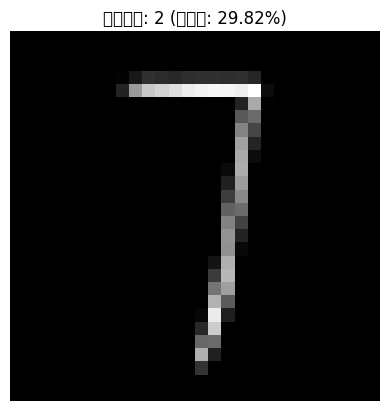

In [22]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# 1. 上传文件
uploaded = files.upload()

for filename in uploaded.keys():
    # 2. 读取并预处理图片
    img = Image.open(filename).convert('L') # 转为灰度图
    img = img.resize((28, 28)) # 调整为 MNIST 标准尺寸

    # 转换为数组
    img_array = np.array(img)

    # 关键步骤：MNIST 是黑底白字。如果你的图片是白底黑字，需要反转颜色
    # 我们通过检查中心区域的平均亮度来简单判断是否需要反转
    if np.mean(img_array) > 127:
        img_array = 255 - img_array

    # 归一化与展平 (匹配之前模型的输入格式)
    img_input = img_array.reshape(1, 28 * 28).astype("float32") / 255

    # 3. 预测
    prediction = model.predict(img_input)
    predicted_label = np.argmax(prediction)
    confidence = np.max(prediction)

    # 4. 可视化结果
    plt.imshow(img_array, cmap='gray')
    plt.title(f"预测结果: {predicted_label} (置信度: {confidence:.2%})")
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20462 (\N{CJK UNIFIED IDEOGRAPH-4FEE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas

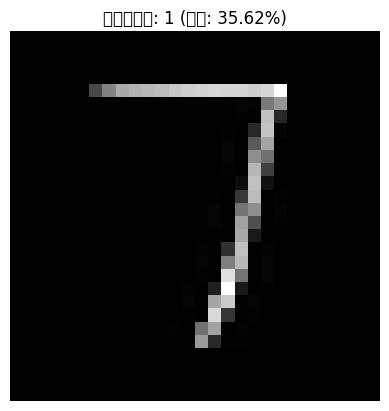

In [23]:
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

def robust_predict(filename):
    # 1. 加载并转为灰度
    img = Image.open(filename).convert('L')

    # 2. 自动反转颜色：确保是黑底白字
    # MNIST 是黑底 (0) 白字 (255)
    img_array = np.array(img)
    if np.mean(img_array) > 127:
        img = ImageOps.invert(img)

    # 3. 核心改进：去除白边并居中 (模拟 MNIST 的预处理)
    # 找到有像素的边界框
    bbox = img.getbbox()
    if bbox:
        img = img.crop(bbox)

    # 缩放至 20x20 (保持比例)，然后放在 28x28 的中心
    img.thumbnail((20, 20), Image.Resampling.LANCZOS)
    new_img = Image.new('L', (28, 28), (0))
    offset = ((28 - img.size[0]) // 2, (28 - img.size[1]) // 2)
    new_img.paste(img, offset)

    # 4. 最终输入处理
    final_array = np.array(new_img)
    img_input = final_array.reshape(1, 28 * 28).astype("float32") / 255

    # 5. 预测
    prediction = model.predict(img_input)
    predicted_label = np.argmax(prediction)

    # 可视化
    plt.imshow(final_array, cmap='gray')
    plt.title(f"修正后预测: {predicted_label} (概率: {np.max(prediction):.2%})")
    plt.axis('off')
    plt.show()

# 使用之前上传的文件 '7.png'
robust_predict('7.png')

### 构建并训练卷积神经网络 (CNN)
CNN 模型更擅长处理图像空间特征，对于手写数字识别通常能达到 99% 以上的准确率。

In [24]:
from keras import layers, models

# 1. 准备数据 (CNN 需要 4D 输入: [batch, height, width, channels])
(train_images_cnn, train_labels_cnn), _ = mnist.load_data()
train_images_cnn = train_images_cnn.reshape((60000, 28, 28, 1)).astype("float32") / 255

# 2. 构建 CNN 模型
cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# 3. 编译与训练
cnn_model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

cnn_model.fit(train_images_cnn, train_labels_cnn, epochs=5, batch_size=64)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9441 - loss: 0.1802
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9847 - loss: 0.0496
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9890 - loss: 0.0359
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9913 - loss: 0.0275
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9933 - loss: 0.0216


### 用训练好的 CNN 再次预测你的图片
现在我们看看这个更强大的模型能否认出你的“7”。

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  fig.canvas

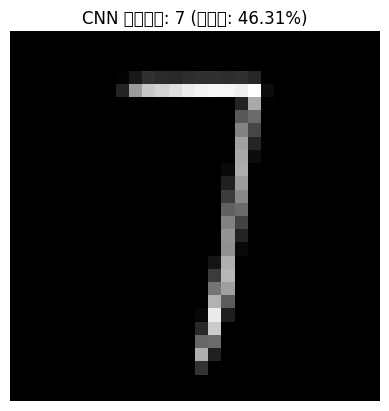

In [25]:
def cnn_predict(filename):
    img = Image.open(filename).convert('L')
    # 简单的预处理以匹配 CNN 输入
    if np.mean(np.array(img)) > 127: img = ImageOps.invert(img)
    img = img.resize((28, 28))
    img_input = np.array(img).reshape(1, 28, 28, 1).astype("float32") / 255

    pred = cnn_model.predict(img_input)
    plt.imshow(img, cmap='gray')
    plt.title(f"CNN 预测结果: {np.argmax(pred)} (置信度: {np.max(pred):.2%})")
    plt.axis('off')
    plt.show()

cnn_predict('7.png')

### Data representations for neural networks
### 神经网络的数据表示

#### Scalars (rank-0 tensors)
#### 标量（0阶张量）

In [ ]:
import numpy as np
x = np.array(12)
x

In [ ]:
x.ndim

#### Vectors (rank-1 tensors)
#### 向量（1阶张量）

In [ ]:
x = np.array([12, 3, 6, 14, 7])
x

In [ ]:
x.ndim

#### Matrices (rank-2 tensors)
#### 矩阵（2阶张量）

In [ ]:
x = np.array([[5, 78, 2, 34, 0],
              [6, 79, 3, 35, 1],
              [7, 80, 4, 36, 2]])
x.ndim

#### Rank-3 tensors and higher-rank tensors
#### 3阶张量及更高阶张量

In [ ]:
x = np.array([[[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]],
              [[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]],
              [[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]]])
x.ndim

#### Key attributes
#### 关键属性

In [ ]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [ ]:
train_images.ndim

In [ ]:
train_images.shape

In [ ]:
train_images.dtype

In [ ]:
import matplotlib.pyplot as plt

digit = train_images[4]
plt.imshow(digit, cmap=plt.cm.binary)
plt.show()

In [ ]:
train_labels[4]

#### Manipulating tensors in NumPy
#### 在 NumPy 中操作张量

In [ ]:
my_slice = train_images[10:100]
my_slice.shape

In [ ]:
my_slice = train_images[10:100, :, :]
my_slice.shape

In [ ]:
my_slice = train_images[10:100, 0:28, 0:28]
my_slice.shape

In [ ]:
my_slice = train_images[:, 14:, 14:]

In [ ]:
my_slice = train_images[:, 7:-7, 7:-7]

#### The notion of data batches
#### 数据批次的概念

In [ ]:
batch = train_images[:128]

In [ ]:
batch = train_images[128:256]

In [ ]:
n = 3
batch = train_images[128 * n : 128 * (n + 1)]

#### Real-world examples of data tensors
#### 现实世界中的数据张量示例

##### Vector data
##### 向量数据

##### Timeseries data or sequence data
##### 时间序列数据或序列数据

##### Image data
##### 图像数据

##### Video data
##### 视频数据

### The gears of neural networks: Tensor operations
### 神经网络的齿轮：张量运算

#### Element-wise operations
#### 逐元素运算

In [ ]:
def naive_relu(x):
    assert len(x.shape) == 2
    x = x.copy()
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i, j] = max(x[i, j], 0)
    return x

In [ ]:
def naive_add(x, y):
    assert len(x.shape) == 2
    assert x.shape == y.shape
    x = x.copy()
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i, j] += y[i, j]
    return x

In [ ]:
import time

x = np.random.random((20, 100))
y = np.random.random((20, 100))

t0 = time.time()
for _ in range(1000):
    z = x + y
    z = np.maximum(z, 0.0)
print("Took: {0:.2f} s".format(time.time() - t0))

In [ ]:
t0 = time.time()
for _ in range(1000):
    z = naive_add(x, y)
    z = naive_relu(z)
print("Took: {0:.2f} s".format(time.time() - t0))

#### Broadcasting
#### 广播

In [ ]:
import numpy as np

X = np.random.random((32, 10))
y = np.random.random((10,))

In [ ]:
y = np.expand_dims(y, axis=0)

In [ ]:
Y = np.tile(y, (32, 1))

In [ ]:
def naive_add_matrix_and_vector(x, y):
    assert len(x.shape) == 2
    assert len(y.shape) == 1
    assert x.shape[1] == y.shape[0]
    x = x.copy()
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i, j] += y[j]
    return x

In [ ]:
import numpy as np

x = np.random.random((64, 3, 32, 10))
y = np.random.random((32, 10))
z = np.maximum(x, y)

#### Tensor product
#### 张量积

In [ ]:
x = np.random.random((32,))
y = np.random.random((32,))

z = np.matmul(x, y)
z = x @ y

In [ ]:
def naive_vector_product(x, y):
    assert len(x.shape) == 1
    assert len(y.shape) == 1
    assert x.shape[0] == y.shape[0]
    z = 0.0
    for i in range(x.shape[0]):
        z += x[i] * y[i]
    return z

In [ ]:
def naive_matrix_vector_product(x, y):
    assert len(x.shape) == 2
    assert len(y.shape) == 1
    assert x.shape[1] == y.shape[0]
    z = np.zeros(x.shape[0])
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            z[i] += x[i, j] * y[j]
    return z

In [ ]:
def naive_matrix_vector_product(x, y):
    z = np.zeros(x.shape[0])
    for i in range(x.shape[0]):
        z[i] = naive_vector_product(x[i, :], y)
    return z

In [ ]:
def naive_matrix_product(x, y):
    assert len(x.shape) == 2
    assert len(y.shape) == 2
    assert x.shape[1] == y.shape[0]
    z = np.zeros((x.shape[0], y.shape[1]))
    for i in range(x.shape[0]):
        for j in range(y.shape[1]):
            row_x = x[i, :]
            column_y = y[:, j]
            z[i, j] = naive_vector_product(row_x, column_y)
    return z

#### Tensor reshaping
#### 张量变型

In [ ]:
train_images = train_images.reshape((60000, 28 * 28))

In [ ]:
x = np.array([[0., 1.],
              [2., 3.],
              [4., 5.]])
x.shape

In [ ]:
x = x.reshape((6, 1))
x

In [ ]:
x = x.reshape((2, 3))
x

In [ ]:
x = np.zeros((300, 20))
x = np.transpose(x)
x.shape

#### Geometric interpretation of tensor operations
#### 张量运算的几何解释

#### A geometric interpretation of deep learning
#### 深度学习的几何解释

### The engine of neural networks: Gradient-based optimization
### 神经网络的引擎：基于梯度的优化

#### What's a derivative?
#### 什么是导数？

#### Derivative of a tensor operation: The gradient
#### 张量运算的导数：梯度

#### Stochastic gradient descent
#### 随机梯度下降

#### Chaining derivatives: The Backpropagation algorithm
#### 链式求导：反向传播算法

##### The chain rule
##### 链式法则

##### Automatic differentiation with computation graphs
##### 利用计算图进行自动微分

### Looking back at our first example
### 回顾我们的第一个例子

In [ ]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

In [ ]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [ ]:
model.fit(
    train_images,
    train_labels,
    epochs=5,
    batch_size=128,
)

#### Reimplementing our first example from scratch
#### 从头开始重新实现我们的第一个例子

##### A simple Dense class
##### 一个简单的 Dense 类

In [ ]:
import keras
from keras import ops

class NaiveDense:
    def __init__(self, input_size, output_size, activation=None):
        self.activation = activation
        self.W = keras.Variable(
            shape=(input_size, output_size), initializer="uniform"
        )
        self.b = keras.Variable(shape=(output_size,), initializer="zeros")

    def __call__(self, inputs):
        x = ops.matmul(inputs, self.W)
        x = x + self.b
        if self.activation is not None:
            x = self.activation(x)
        return x

    @property
    def weights(self):
        return [self.W, self.b]

##### A simple Sequential class
##### 一个简单的 Sequential 类

In [ ]:
class NaiveSequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, inputs):
        x = inputs
        for layer in self.layers:
            x = layer(x)
        return x

    @property
    def weights(self):
        weights = []
        for layer in self.layers:
            weights += layer.weights
        return weights

In [ ]:
model = NaiveSequential(
    [
        NaiveDense(input_size=28 * 28, output_size=512, activation=ops.relu),
        NaiveDense(input_size=512, output_size=10, activation=ops.softmax),
    ]
)
assert len(model.weights) == 4

##### A batch generator
##### 一个批次生成器

In [ ]:
import math

class BatchGenerator:
    def __init__(self, images, labels, batch_size=128):
        assert len(images) == len(labels)
        self.index = 0
        self.images = images
        self.labels = labels
        self.batch_size = batch_size
        self.num_batches = math.ceil(len(images) / batch_size)

    def next(self):
        images = self.images[self.index : self.index + self.batch_size]
        labels = self.labels[self.index : self.index + self.batch_size]
        self.index += self.batch_size
        return images, labels

#### Running one training step
#### 运行一个训练步骤

##### The weight update step
##### 权重更新步骤

In [ ]:
learning_rate = 1e-3

def update_weights(gradients, weights):
    for g, w in zip(gradients, weights):
        w.assign(w - g * learning_rate)

In [ ]:
from keras import optimizers

optimizer = optimizers.SGD(learning_rate=1e-3)

def update_weights(gradients, weights):
    optimizer.apply_gradients(zip(gradients, weights))

##### Gradient computation
##### 梯度计算

In [ ]:
%%backend tensorflow
import tensorflow as tf

x = tf.zeros(shape=())
with tf.GradientTape() as tape:
    y = 2 * x + 3
grad_of_y_wrt_x = tape.gradient(y, x)

In [ ]:
%%backend tensorflow
def one_training_step(model, images_batch, labels_batch):
    with tf.GradientTape() as tape:
        predictions = model(images_batch)
        loss = ops.sparse_categorical_crossentropy(labels_batch, predictions)
        average_loss = ops.mean(loss)
    gradients = tape.gradient(average_loss, model.weights)
    update_weights(gradients, model.weights)
    return average_loss

#### The full training loop
#### 完整的训练循环

In [ ]:
%%backend tensorflow
def fit(model, images, labels, epochs, batch_size=128):
    for epoch_counter in range(epochs):
        print(f"Epoch {epoch_counter}")
        batch_generator = BatchGenerator(images, labels)
        for batch_counter in range(batch_generator.num_batches):
            images_batch, labels_batch = batch_generator.next()
            loss = one_training_step(model, images_batch, labels_batch)
            if batch_counter % 100 == 0:
                print(f"loss at batch {batch_counter}: {loss:.2f}")

In [ ]:
%%backend tensorflow
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

fit(model, train_images, train_labels, epochs=10, batch_size=128)

#### Evaluating the model
#### 评估模型

In [ ]:
%%backend tensorflow
predictions = model(test_images)
predicted_labels = ops.argmax(predictions, axis=1)
matches = predicted_labels == test_labels
f"accuracy: {ops.mean(matches):.2f}"